1. Import Libraries


In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

df = pd.read_csv("task 1 dataset.csv")

2. Load Dataset

In [2]:
df = pd.read_csv("task 1 dataset.csv")

In [3]:
df.head()

,OrderID,Date,CustomerID,Product,Quantity,UnitPrice,ShippingAddress,PaymentMethod,OrderStatus,TrackingNumber,ItemsInCart,CouponCode,ReferralSource,TotalPrice
0,ORD200000,2023-01-04,C72649,Monitor,5,570.62,928 Main St,Debit Card,Shipped,TRK37947903,7,SAVE10,Instagram,2853.10
1,ORD200001,2024-08-23,C75739,Phone,2,151.35,823 Main St,Online,Shipped,TRK91186779,3,SAVE10,Referral,302.70
2,ORD200002,2024-02-27,C81728,Tablet,5,550.68,512 Main St,Credit Card,Cancelled,TRK42903982,8,FREESHIP,Email,2753.40
3,ORD200003,2023-10-15,C33540,Chair,1,273.19,275 Main St,Debit Card,Returned,TRK62788070,5,SAVE10,Facebook,273.19
4,ORD200004,2025-05-08,C81840,Printer,4,626.01,668 Main St,Online,Delivered,TRK29241424,8,SAVE10,Email,2504.04


In [4]:
df.shape

(1200, 14)

3. Missing Value Analysis

In [5]:
df.isnull().sum()

OrderID              0
Date                 0
CustomerID           0
Product              0
Quantity             0
UnitPrice            0
ShippingAddress      0
PaymentMethod        0
OrderStatus          0
TrackingNumber       0
ItemsInCart          0
CouponCode         309
ReferralSource       0
TotalPrice           0
dtype: int64

The CouponCode column contains 309 missing values (25.75% of the dataset).
This indicates that no coupon was applied by the customer while ordering instead of a statistical anomaly. Therefore these missing values were simply replaced by "No Coupon" instead of further analysis.

In [6]:
df["CouponCode"] = df["CouponCode"].fillna("No Coupon")

In [7]:
df["CouponCode"].isnull().sum()


np.int64(0)

4. Data Visualization and Feature Engineering


In [8]:
df["Date"] = pd.to_datetime(df["Date"])
df["Month"] = df["Date"].dt.month_name()

In [9]:
df[["Date", "Month"]].head()

,Date,Month
0,2023-01-04,January
1,2024-08-23,August
2,2024-02-27,February
3,2023-10-15,October
4,2025-05-08,May


In [10]:
df["WeekendOrder"] = df["Date"].dt.dayofweek >= 5

In [11]:
df["DiscountUsed"] = np.where(
    df["CouponCode"] == "No Coupon",
    0,
    1
)

In [12]:
df["RevenuePerItem"] = df["TotalPrice"] / df["Quantity"]

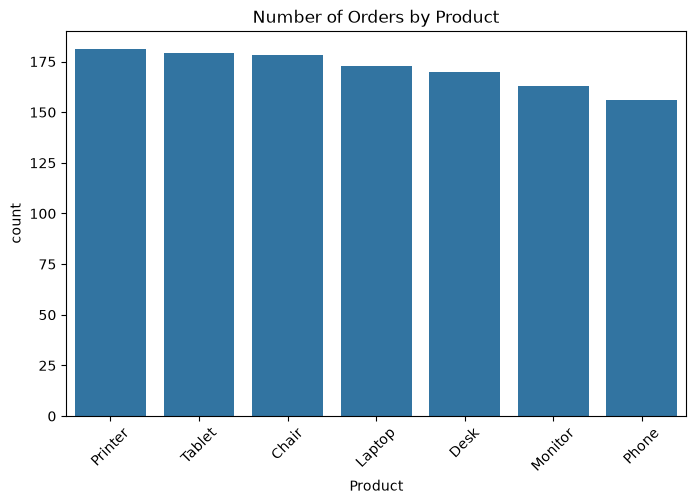

In [30]:
plt.figure(figsize=(8,5))
sns.countplot(data=df, x="Product", order=df["Product"].value_counts().index)
plt.title("Number of Orders by Product")
plt.xticks(rotation=45)
plt.show()

Printers were the most popular products, followed closely by Tablets and Chairs. Phones were the least ordered items.

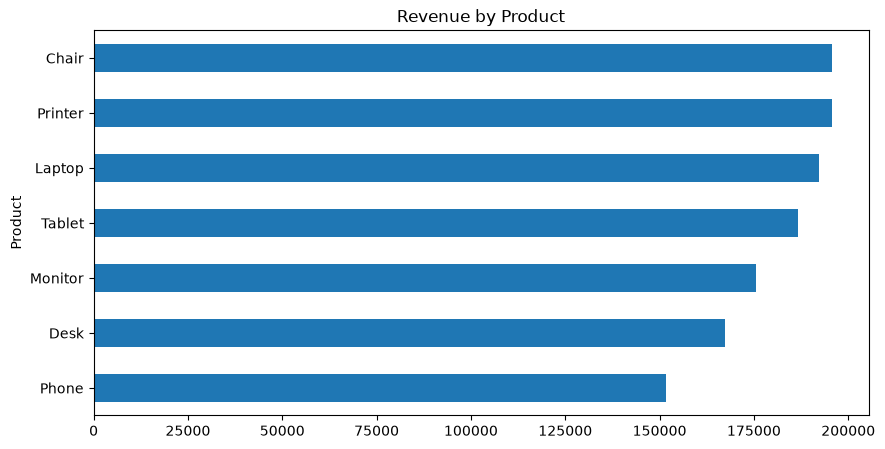

In [13]:
product_sales = df.groupby("Product")["TotalPrice"].sum()

plt.figure(figsize=(10,5))
product_sales.sort_values().plot(kind="barh")
plt.title("Revenue by Product")
plt.show()

Chair and Printer generated the most revenue whereas Phone generated the least revenue

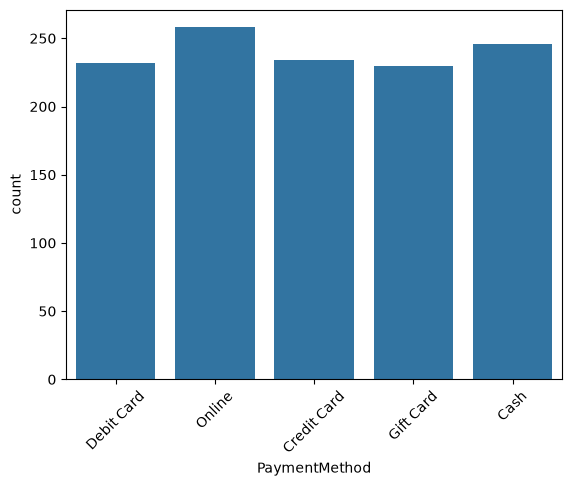

In [14]:
sns.countplot(data=df, x="PaymentMethod")
plt.xticks(rotation=45)
plt.show()

Online Payment mode was the most frequenty used payment method whereas Gift Card was the least used method.

In [21]:
df["Product"].value_counts()

Product
Printer    181
Tablet     179
Chair      178
Laptop     173
Desk       170
Monitor    163
Phone      156
Name: count, dtype: int64

In [22]:
df["OrderStatus"].value_counts()

OrderStatus
Cancelled    250
Returned     247
Pending      237
Shipped      235
Delivered    231
Name: count, dtype: int64

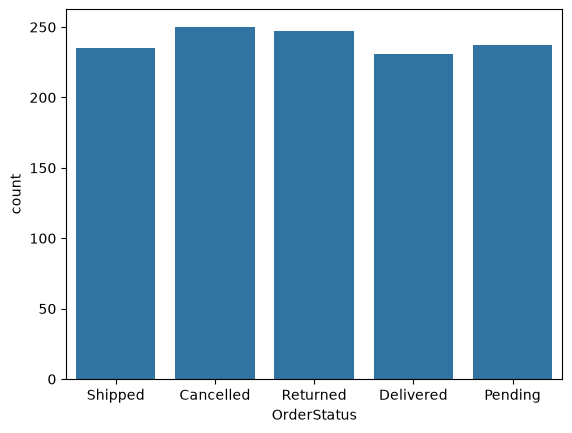

In [15]:
sns.countplot(data=df, x="OrderStatus")
plt.show()

Cancelled orders showed up the most, followed closely by returned. 

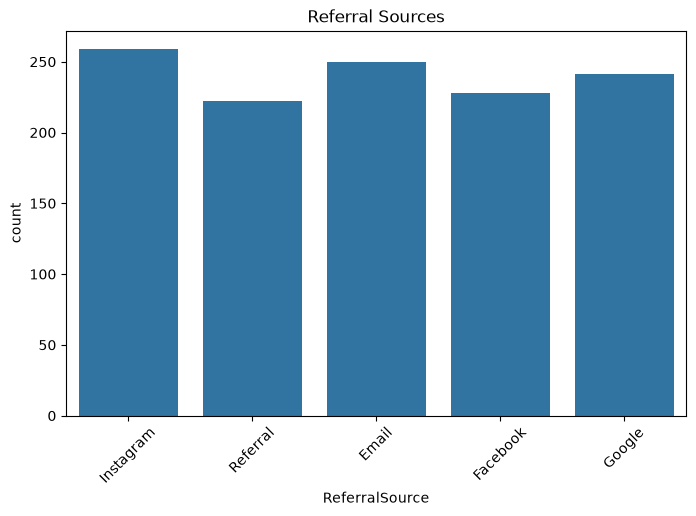

In [27]:
plt.figure(figsize=(8,5))
sns.countplot(data=df, x="ReferralSource")

plt.xticks(rotation=45)
plt.title("Referral Sources")
plt.show()

Instagram led in referral sources whereas the least came through referrals

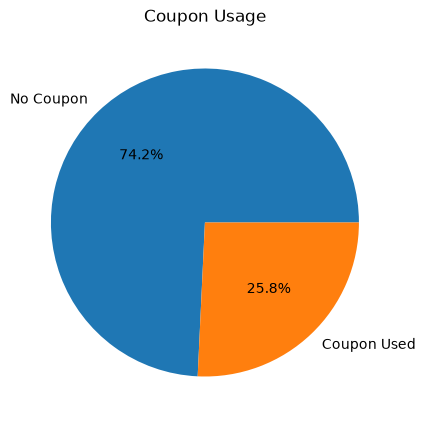

In [28]:
coupon = df["DiscountUsed"].value_counts()

plt.figure(figsize=(5,5))
plt.pie(
    coupon,
    labels=["No Coupon","Coupon Used"],
    autopct="%1.1f%%"
)

plt.title("Coupon Usage")
plt.show()

Roughly 3/4ths of the orders used no coupons.

In [16]:
df.to_csv("cleaned_dataset.csv", index=False)

In [17]:
df.to_csv("checkpoint_after_cleaning_dataset.csv", index=False)

5. Outlier Detection

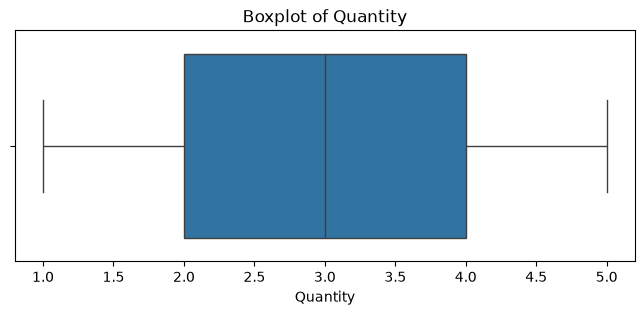

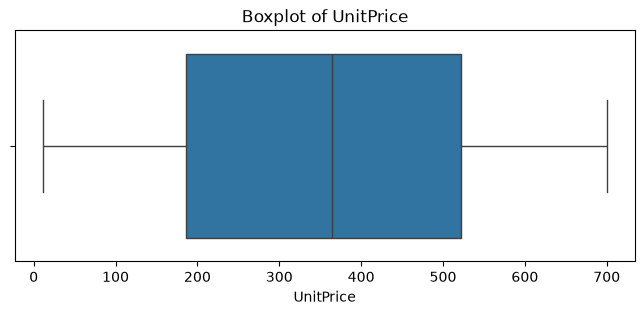

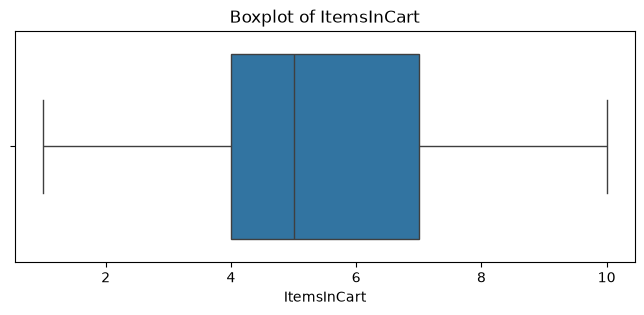

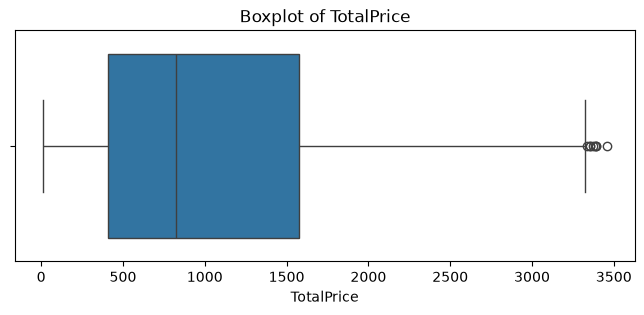

In [18]:
numeric_cols = ["Quantity", "UnitPrice", "ItemsInCart", "TotalPrice"]

for col in numeric_cols:
    plt.figure(figsize=(8,3))
    sns.boxplot(x=df[col])
    plt.title(f"Boxplot of {col}")
    plt.show()

In [19]:
for col in numeric_cols:
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1

    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR

    outliers = df[(df[col] < lower) | (df[col] > upper)]

    print(f"{col}: {len(outliers)} outliers")

Quantity: 0 outliers
UnitPrice: 0 outliers
ItemsInCart: 0 outliers
TotalPrice: 8 outliers


In [20]:
Q1 = df["TotalPrice"].quantile(0.25)
Q3 = df["TotalPrice"].quantile(0.75)
IQR = Q3 - Q1

lower = Q1 - 1.5 * IQR
upper = Q3 + 1.5 * IQR

outliers = df[(df["TotalPrice"] < lower) | (df["TotalPrice"] > upper)]

outliers[["Product", "Quantity", "UnitPrice", "TotalPrice"]]

,Product,Quantity,UnitPrice,TotalPrice
107,Printer,5,670.75,3353.75
326,Laptop,5,670.48,3352.40
328,Tablet,5,674.04,3370.20
469,Chair,5,676.98,3384.90
632,Laptop,5,678.16,3390.80
789,Tablet,5,691.28,3456.40
1065,Printer,5,666.80,3334.00
1122,Monitor,5,678.19,3390.95




The IQR method was applied to Quantity, UnitPrice, ItemsInCart, and TotalPrice. No outliers were detected in Quantity, UnitPrice, or ItemsInCart.
However, 8 outliers were detected in TotalPrice. But these records represented real expensive purchases rather than data-entry errors. Therefore, the observations were not changed to preserve information and data integrity.

In [29]:
df.to_csv("cleaned_dataset.csv", index=False)

6. Conclusion:

The dataset contained 1200 records and 14 attributes.

Missing values in CouponCode were handled by replacing them with "No Coupon".

Four new features were created: Month, WeekendOrder, DiscountUsed, and RevenuePerItem.

Outlier analysis using the IQR method identified eight high-value transactions, which were unchanged because they represented real activity.

Visualizations helped in identifying trends in product sales, revenue, payment methods, order status, referral sources, and coupon usage.

The final cleaned dataset is ready for further analysis or machine learning.